# Relative Strength Index (RSI)

---

## Importing libraries

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

---

## Cleaning data

In [2]:
tickers = ['HDFCBANK.NS', 'ICICIBANK.NS', '^NSEBANK']
data = yf.download(tickers, period = "2y", auto_adjust=True)
data_dropped = data[~(data == 0).any(axis=1)].copy()
data_dropped = data_dropped[~data_dropped.isna().any(axis=1)].copy()
data_cleaned = data_dropped.copy()
data_cleaned['Volume'] = data_cleaned['Volume'].astype('float64').copy()

[*********************100%***********************]  3 of 3 completed


---

## Function to calculate RSI

In [3]:
def cal_rsi(close_d, window=14):
    difference = close_d.diff()
    gain = (difference.where(difference > 0, 0)) # Place the value in gain series if diff > 0 while placing 0 in the loss series for this day.
    loss = (-difference.where(difference < 0, 0)) # Place the value in loss series if diff > 0 while placing 0 in the loss series for this day.

    # Wilder's Smoothing Method
    #avg_gain = gain.ewm(com=13, min_periods=14).mean()
    #avg_loss = loss.ewm(com=13, min_periods=14).mean()
    # The above two lines are the same as the below 2 in work, as alpha is calculated behind the scenes 1/1+com

    avg_gain = gain.ewm(alpha=1/window, min_periods=window).mean()
    avg_loss = loss.ewm(alpha=1/window, min_periods=window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

In [4]:
# Putting RSI values in a dataframe
rsi_ticker = pd.DataFrame()
for ticker in tickers:
    rsi_ticker[ticker] = cal_rsi(data_cleaned['Close'][ticker])

---

## Plotting RSI

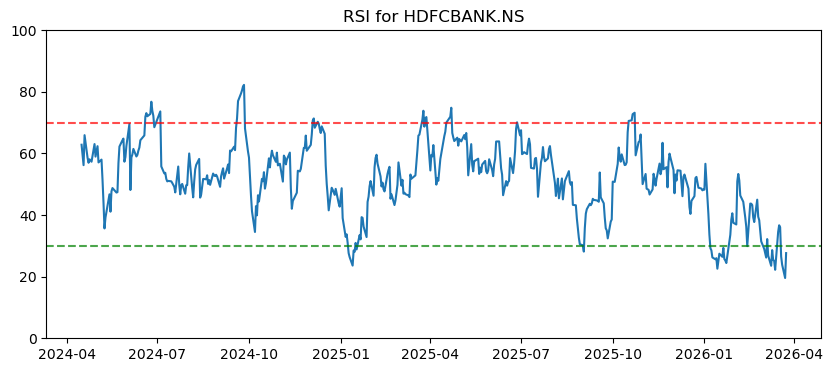

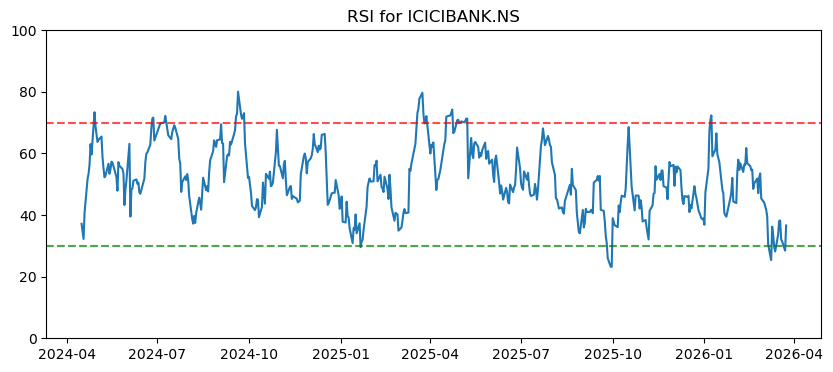

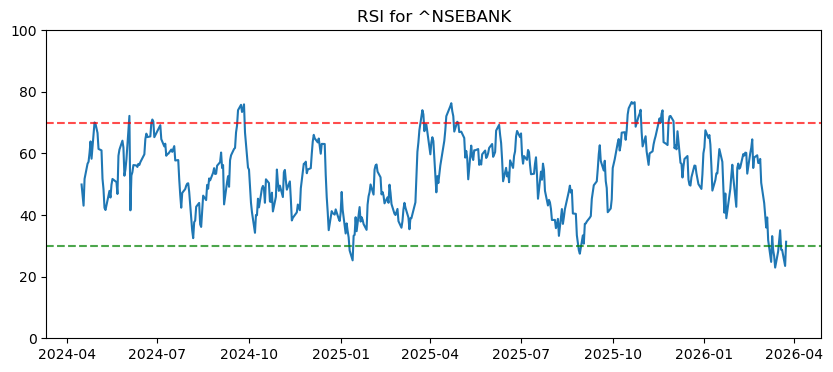

In [5]:
viz_df = rsi_ticker.dropna().copy()

for ticker in tickers:
    plt.figure(figsize=(10, 4))
    sns.lineplot(data=viz_df, x=viz_df.index, y=ticker)
    plt.grid(False) # For removing grid
    plt.axhline(70, color='red', linestyle='--', alpha=0.7)
    plt.axhline(30, color='green', linestyle='--', alpha=0.7)
    plt.ylim(0, 100)
    plt.title(f'RSI for {ticker}')
    plt.ylabel("")
    plt.xlabel("")
    plt.show()

---